# XAU/USD — PA Engulf + MACD + EMA Filter

**Instrument:** XAU/USD (Gold) | **Timeframe:** 15m | **Period:** 2021–2025

**BUY:** PA Bullish Engulf (Wick Grab) + MACD Line > Signal Line + Close > EMA50

**SELL:** PA Bearish Engulf (Wick Grab) + MACD Line < Signal Line + Close < EMA50

**SL:** Low/High of signal bar (max 0.4% of price) | **TP:** RR 1:1 | **Risk:** 3% per trade (compound)

---
### How to run
1. Click **Runtime → Run All**
2. Upload your **15-minute XAU/USD CSV file** when prompted (e.g. `XAU_15m_2021-2025.csv`)
3. Results will print automatically

In [1]:
!pip install pandas numpy matplotlib -q
print('Library พร้อมแล้ว!')

Library พร้อมแล้ว!


In [2]:
from google.colab import files
print('กรุณาเลือกไฟล์ XAUUSD5.csv...')
uploaded = files.upload()
print('อัปโหลดสำเร็จ!')

กรุณาเลือกไฟล์ XAUUSD5.csv...


Saving XAU_15m_2021-2025 (1).csv to XAU_15m_2021-2025 (1).csv
อัปโหลดสำเร็จ!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ===== CONFIG =====
INITIAL_CAPITAL = 10000.0
RISK_PERCENT    = 0.03
RR_RATIO        = 1.0
MAX_SL_PCT      = 0.4
MACD_FAST       = 10
MACD_SLOW       = 30
MACD_SIGNAL     = 9

# EMA Trend Filter
EMA_FAST        = 50     # Price must close above (BUY) / below (SELL) this EMA

# ==================

print(f'Config: ทุน ${INITIAL_CAPITAL:,.0f} | เสี่ยง {RISK_PERCENT*100:.0f}% | RR 1:{RR_RATIO} | SL max {MAX_SL_PCT}%')
print(f'MACD({MACD_FAST}/{MACD_SLOW}/{MACD_SIGNAL}) | EMA Filter: EMA{EMA_FAST}')


Config: ทุน $10,000 | เสี่ยง 3% | RR 1:1.0 | SL max 0.4%
MACD(10/30/9) | EMA Filter: EMA50


In [4]:
print('กำลังโหลดข้อมูล...')

filename = list(uploaded.keys())[0]

# อ่านไฟล์ — รองรับทั้ง xlsx และ csv
if filename.endswith('.xlsx') or filename.endswith('.xls'):
    df_raw = pd.read_excel(filename)
else:
    df_raw = pd.read_csv(filename, header=None)
    first_val = str(df_raw.iloc[0, 0])
    if first_val.lower() in ['date', 'datetime'] or not any(c.isdigit() for c in first_val[:4]):
        df_raw = pd.read_csv(filename)
    else:
        if df_raw.shape[1] == 7:
            df_raw.columns = ['date','time','open','high','low','close','volume']
        elif df_raw.shape[1] == 6:
            df_raw.columns = ['date','time','open','high','low','close']
        else:
            df_raw.columns = ['date','time','open','high','low','close'] + [f'col{i}' for i in range(df_raw.shape[1]-6)]

df_raw.columns = [c.strip().lower() if isinstance(c, str) else c for c in df_raw.columns]

# สร้าง datetime
# ไฟล์นี้ date format = ปี.วัน.เดือน (%Y.%d.%m)
dt_str = df_raw['date'].astype(str).str.strip() + ' ' + df_raw['time'].astype(str).str.strip()

# ลอง parse หลาย format จนกว่าจะสำเร็จ
for fmt, label in [('%Y.%d.%m %H:%M', 'ปี.วัน.เดือน'),
                   ('%Y.%m.%d %H:%M', 'ปี.เดือน.วัน'),
                   (None, 'auto')]:
    if fmt:
        dt_parsed = pd.to_datetime(dt_str, format=fmt, errors='coerce')
    else:
        dt_parsed = pd.to_datetime(dt_str, dayfirst=True, errors='coerce')

    pct_ok = dt_parsed.notna().sum() / len(dt_parsed) * 100
    if pct_ok > 90:
        df_raw['datetime'] = dt_parsed
        print(f'Parse สำเร็จด้วย format: {label} ({pct_ok:.1f}%)')
        break

df_raw = df_raw.dropna(subset=['datetime']).sort_values('datetime').set_index('datetime')

df = df_raw[['open','high','low','close']].copy()
df.columns = ['Open','High','Low','Close']
df = df.apply(pd.to_numeric, errors='coerce').dropna()

print(f'โหลดสำเร็จ! {len(df):,} แท่ง')
print(f'ช่วงเวลา: {df.index[0]} ถึง {df.index[-1]}')
print(f'ราคาล่าสุด: {df["Close"].iloc[-1]:.2f}')

กำลังโหลดข้อมูล...
Parse สำเร็จด้วย format: ปี.เดือน.วัน (100.0%)
โหลดสำเร็จ! 118,088 แท่ง
ช่วงเวลา: 2021-01-04 01:00:00 ถึง 2025-12-31 23:45:00
ราคาล่าสุด: 4318.21


In [5]:
print(f'คำนวณ MACD, EMA Filter และ Price Action Signal...')

# MACD
ema_fast        = df['Close'].ewm(span=MACD_FAST,   adjust=False).mean()
ema_slow        = df['Close'].ewm(span=MACD_SLOW,   adjust=False).mean()
df['macd_line'] = ema_fast - ema_slow
df['macd_sig']  = df['macd_line'].ewm(span=MACD_SIGNAL, adjust=False).mean()
df['macd_bull'] = df['macd_line'] > df['macd_sig']
df['macd_bear'] = df['macd_line'] < df['macd_sig']

# EMA Trend Filter — single line
df['ema_f']    = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['ema_bull'] = df['Close'] > df['ema_f']  # price above EMA = uptrend
df['ema_bear'] = df['Close'] < df['ema_f']  # price below EMA = downtrend

# Price Action: Engulf Wick Grab
df['high1']     = df['High'].shift(1)
df['low1']      = df['Low'].shift(1)
df['high2']     = df['High'].shift(2)
df['low2']      = df['Low'].shift(2)
df['prevHigh2'] = df[['high1','high2']].max(axis=1)
df['prevLow2']  = df[['low1','low2']].min(axis=1)

df['pa_buy'] = (
    (df['Close'] > df['Open']) &
    (df['Low']   < df['prevLow2']) &
    (df['Close'] > df['prevHigh2'])
)
df['pa_sell'] = (
    (df['Close'] < df['Open']) &
    (df['High']  > df['prevHigh2']) &
    (df['Close'] < df['prevLow2'])
)

# Combined: PA + MACD + EMA
df['buy_signal']  = df['pa_buy']  & df['macd_bull'] & df['ema_bull']
df['sell_signal'] = df['pa_sell'] & df['macd_bear'] & df['ema_bear']
df = df.dropna()

ema_label = f'EMA{EMA_FAST}'
print(f'PA Buy    : {df["pa_buy"].sum():,} | หลัง MACD: {(df["pa_buy"] & df["macd_bull"]).sum():,} | หลัง {ema_label}: {df["buy_signal"].sum():,}')
print(f'PA Sell   : {df["pa_sell"].sum():,} | หลัง MACD: {(df["pa_sell"] & df["macd_bear"]).sum():,} | หลัง {ema_label}: {df["sell_signal"].sum():,}')


คำนวณ MACD, EMA Filter และ Price Action Signal...
PA Buy    : 1,006 | หลัง MACD: 575 | หลัง EMA50: 389
PA Sell   : 1,038 | หลัง MACD: 620 | หลัง EMA50: 369


In [6]:
print('กำลังรัน Backtest...')

capital    = INITIAL_CAPITAL
trades     = []
in_trade   = False
skipped_sl = 0

start_i = MACD_SLOW + MACD_SIGNAL + 2

for i in range(start_i, len(df) - 1):
    row = df.iloc[i]

    if in_trade:
        trade = trades[-1]
        hi = float(row['High'])
        lo = float(row['Low'])

        if trade['direction'] == 'BUY':
            if lo <= trade['sl_price']:
                loss = trade['risk_amount']
                capital -= loss
                trades[-1].update({'exit_price': trade['sl_price'], 'exit_time': str(row.name),
                                   'result': 'SL', 'pnl': round(-loss,2), 'capital': round(capital,2)})
                in_trade = False
            elif hi >= trade['tp_price']:
                profit = trade['risk_amount'] * RR_RATIO
                capital += profit
                trades[-1].update({'exit_price': trade['tp_price'], 'exit_time': str(row.name),
                                   'result': 'TP', 'pnl': round(profit,2), 'capital': round(capital,2)})
                in_trade = False
        else:
            if hi >= trade['sl_price']:
                loss = trade['risk_amount']
                capital -= loss
                trades[-1].update({'exit_price': trade['sl_price'], 'exit_time': str(row.name),
                                   'result': 'SL', 'pnl': round(-loss,2), 'capital': round(capital,2)})
                in_trade = False
            elif lo <= trade['tp_price']:
                profit = trade['risk_amount'] * RR_RATIO
                capital += profit
                trades[-1].update({'exit_price': trade['tp_price'], 'exit_time': str(row.name),
                                   'result': 'TP', 'pnl': round(profit,2), 'capital': round(capital,2)})
                in_trade = False
        continue

    entry_price = float(row['Close'])

    if bool(row['buy_signal']):
        sl_price    = float(row['Low'])
        sl_distance = entry_price - sl_price
        if sl_distance <= 0 or sl_distance > (entry_price * MAX_SL_PCT / 100):
            skipped_sl += 1
            continue
        tp_price    = round(entry_price + sl_distance * RR_RATIO, 2)
        risk_amount = capital * RISK_PERCENT
        trades.append({
            'direction': 'BUY', 'entry_time': str(row.name),
            'entry_price': round(entry_price,2), 'sl_price': round(sl_price,2),
            'tp_price': tp_price, 'sl_distance': round(sl_distance,2),
            'risk_amount': round(risk_amount,2),
            'macd_line': round(float(row['macd_line']),4),
            'macd_sig':  round(float(row['macd_sig']),4),
            'exit_price': None, 'exit_time': None,
            'result': None, 'pnl': None, 'capital': None
        })
        in_trade = True

    elif bool(row['sell_signal']):
        sl_price    = float(row['High'])
        sl_distance = sl_price - entry_price
        if sl_distance <= 0 or sl_distance > (entry_price * MAX_SL_PCT / 100):
            skipped_sl += 1
            continue
        tp_price    = round(entry_price - sl_distance * RR_RATIO, 2)
        risk_amount = capital * RISK_PERCENT
        trades.append({
            'direction': 'SELL', 'entry_time': str(row.name),
            'entry_price': round(entry_price,2), 'sl_price': round(sl_price,2),
            'tp_price': tp_price, 'sl_distance': round(sl_distance,2),
            'risk_amount': round(risk_amount,2),
            'macd_line': round(float(row['macd_line']),4),
            'macd_sig':  round(float(row['macd_sig']),4),
            'exit_price': None, 'exit_time': None,
            'result': None, 'pnl': None, 'capital': None
        })
        in_trade = True

df_trades = pd.DataFrame(trades) if trades else pd.DataFrame()
print(f'Backtest เสร็จ!')
print(f'Signal ที่เข้าได้ : {len(trades)} ครั้ง')
print(f'Signal ที่ Skip   : {skipped_sl} ครั้ง (SL > {MAX_SL_PCT}%)')


กำลังรัน Backtest...
Backtest เสร็จ!
Signal ที่เข้าได้ : 641 ครั้ง
Signal ที่ Skip   : 82 ครั้ง (SL > 0.4%)


In [7]:
if df_trades.empty:
    print('ไม่พบ Signal')
else:
    completed = df_trades.dropna(subset=['result'])
    pending   = df_trades[df_trades['result'].isna()]

    if completed.empty:
        print('ยังไม่มี Trade ที่ปิด')
    else:
        total     = len(completed)
        wins      = completed[completed['result'] == 'TP']
        loses     = completed[completed['result'] == 'SL']
        buys      = completed[completed['direction'] == 'BUY']
        sells     = completed[completed['direction'] == 'SELL']
        buy_wins  = buys[buys['result']   == 'TP']
        sell_wins = sells[sells['result'] == 'TP']

        wr        = len(wins) / total * 100
        total_pnl = completed['pnl'].sum()
        final_cap = completed['capital'].iloc[-1]
        peak      = completed['capital'].cummax()
        max_dd    = abs(((completed['capital'] - peak) / peak * 100).min())
        gp        = wins['pnl'].sum()       if not wins.empty  else 0
        gl        = abs(loses['pnl'].sum()) if not loses.empty else 0
        pf        = gp / gl                 if gl > 0          else float('inf')
        buy_wr    = len(buy_wins)/len(buys)*100   if len(buys)  > 0 else 0
        sell_wr   = len(sell_wins)/len(sells)*100 if len(sells) > 0 else 0

        print('=' * 58)
        print(f'    XAU/USD — PA Engulf + MACD({MACD_FAST}/{MACD_SLOW}/{MACD_SIGNAL})')
        print('=' * 58)
        print(f'  ทุนเริ่มต้น        : ${INITIAL_CAPITAL:,.2f}')
        print(f'  ทุนสุดท้าย         : ${final_cap:,.2f}')
        print(f'  กำไร/ขาดทุนรวม    : ${total_pnl:+,.2f}')
        print(f'  Return             : {(final_cap/INITIAL_CAPITAL-1)*100:+.2f}%')
        print('-' * 58)
        print(f'  Trade ที่เข้าได้    : {total}  (เปิดอยู่: {len(pending)})')
        print(f'  Trade ที่ Skip      : {skipped_sl}  (SL > {MAX_SL_PCT}%)')
        print(f'  ชนะ (TP)           : {len(wins)}  | แพ้ (SL): {len(loses)}')
        print(f'  Win Rate รวม       : {wr:.1f}%')
        print(f'  Profit Factor      : {pf:.2f}')
        print(f'  Max Drawdown       : {max_dd:.2f}%')
        print('-' * 58)
        # Win/Loss Streak
        max_win_streak = 0
        max_loss_streak = 0
        cur_win = 0
        cur_loss = 0
        for _, r in completed.iterrows():
            if r['result'] == 'TP':
                cur_win += 1
                cur_loss = 0
                max_win_streak = max(max_win_streak, cur_win)
            else:
                cur_loss += 1
                cur_win = 0
                max_loss_streak = max(max_loss_streak, cur_loss)

        print(f'  BUY  : {len(buys):3d} trade | Win Rate: {buy_wr:.1f}%')
        print(f'  SELL : {len(sells):3d} trade | Win Rate: {sell_wr:.1f}%')
        print('-' * 58)
        print(f'  Max Win Streak     : {max_win_streak} ไม้ติด')
        print(f'  Max Loss Streak    : {max_loss_streak} ไม้ติด')
        print('=' * 58)


        # ===== Conditional Probability =====
        print(f'\n{"="*58}')
        print(f'    โอกาสชนะ/แพ้ ตามผลก่อนหน้า (Conditional Probability)')
        print(f'{"="*58}')
        results = completed['result'].tolist()
        base_wr = len(wins) / total * 100
        print(f'  Win Rate ปกติ (baseline) : {base_wr:.1f}%')
        print(f'  {"—"*50}')

        # นับ conditional prob สูงสุด 5 streak
        for streak_len in range(1, 6):
            for outcome in ['TP', 'SL']:
                label = 'ชนะ' if outcome == 'TP' else 'แพ้'
                total_match = 0
                next_win    = 0
                next_loss   = 0
                for idx in range(streak_len, len(results)):
                    streak = results[idx-streak_len:idx]
                    if all(r == outcome for r in streak):
                        total_match += 1
                        if results[idx] == 'TP':
                            next_win += 1
                        else:
                            next_loss += 1
                if total_match >= 5:  # แสดงเฉพาะที่มีตัวอย่างพอ
                    pct_win  = next_win  / total_match * 100
                    pct_loss = next_loss / total_match * 100
                    diff     = pct_win - base_wr
                    signal   = '⬆' if diff > 3 else ('⬇' if diff < -3 else '➡')
                    print(f'  {label} {streak_len} ติด ({total_match:>3}ครั้ง) → ชนะ {pct_win:>5.1f}%  แพ้ {pct_loss:>5.1f}%  {signal} ({diff:+.1f}% vs baseline)')
        print(f'{"="*58}')

        # ===== ผลรายปี =====
        completed['year'] = pd.to_datetime(completed['entry_time']).dt.year
        print(f'\n{"="*58}')
        print(f'    ผลแยกรายปี')
        print(f'{"="*58}')
        print(f'  {"ปี":>6} | {"Trades":>6} | {"Win":>4} | {"Loss":>4} | {"WR%":>6} | {"PnL":>12} | {"Return%":>9}')
        print(f'  {"-"*52}')

        for year, grp in completed.groupby('year'):
            yr_wins  = grp[grp['result'] == 'TP']
            yr_loses = grp[grp['result'] == 'SL']
            yr_total = len(grp)
            yr_w     = len(yr_wins)
            yr_l     = len(yr_loses)
            yr_wr    = yr_w / yr_total * 100 if yr_total > 0 else 0
            yr_pnl   = grp['pnl'].sum()
            yr_gp    = yr_wins['pnl'].sum() if not yr_wins.empty else 0
            yr_gl    = abs(yr_loses['pnl'].sum()) if not yr_loses.empty else 0
            yr_pf    = yr_gp / yr_gl if yr_gl > 0 else float('inf')

            # Return ของปีนั้น: ทุนต้นปี vs ทุนปลายปี
            yr_start_cap = grp['capital'].iloc[0] - grp['pnl'].iloc[0]  # ทุนก่อน trade แรกของปี
            yr_end_cap   = grp['capital'].iloc[-1]
            yr_ret       = (yr_end_cap / yr_start_cap - 1) * 100 if yr_start_cap > 0 else 0

            print(f'  {year:>6} | {yr_total:>6} | {yr_w:>4} | {yr_l:>4} | {yr_wr:>5.1f}% | ${yr_pnl:>+10,.2f} | {yr_ret:>+8.1f}%')

        print(f'{"="*58}')

    XAU/USD — PA Engulf + MACD(10/30/9)
  ทุนเริ่มต้น        : $10,000.00
  ทุนสุดท้าย         : $34,621.16
  กำไร/ขาดทุนรวม    : $+24,621.16
  Return             : +246.21%
----------------------------------------------------------
  Trade ที่เข้าได้    : 641  (เปิดอยู่: 0)
  Trade ที่ Skip      : 82  (SL > 0.4%)
  ชนะ (TP)           : 346  | แพ้ (SL): 295
  Win Rate รวม       : 54.0%
  Profit Factor      : 1.13
  Max Drawdown       : 38.53%
----------------------------------------------------------
  BUY  : 326 trade | Win Rate: 51.8%
  SELL : 315 trade | Win Rate: 56.2%
----------------------------------------------------------
  Max Win Streak     : 9 ไม้ติด
  Max Loss Streak    : 7 ไม้ติด

    โอกาสชนะ/แพ้ ตามผลก่อนหน้า (Conditional Probability)
  Win Rate ปกติ (baseline) : 54.0%
  ——————————————————————————————————————————————————
  ชนะ 1 ติด (346ครั้ง) → ชนะ  54.3%  แพ้  45.7%  ➡ (+0.4% vs baseline)
  แพ้ 1 ติด (294ครั้ง) → ชนะ  53.7%  แพ้  46.3%  ➡ (-0.2% vs baseline)
  ชนะ 2 ต

In [8]:
# ===== RISK METRICS =====
import numpy as np

# Return ต่อ trade
returns = completed['pnl'] / (completed['capital'] - completed['pnl'])

# ช่วงเวลาจริง
years_span = (pd.to_datetime(completed['exit_time'].dropna()).max() -
              pd.to_datetime(completed['entry_time'].dropna()).min()).days / 365.25
trades_per_year = len(completed) / years_span

# 1. Sharpe Ratio (trade-based annualized)
sharpe = returns.mean() / returns.std() * np.sqrt(trades_per_year)

# 2. Sortino Ratio (downside deviation only)
downside = returns[returns < 0].std()
# Guard: if downside variance is negligible (fixed risk system),
# Sortino will equal Sharpe as both measure the same risk profile
if downside < 0.0001:
    sortino = sharpe  # fixed-risk system: Sortino ≈ Sharpe by design
else:
    sortino = returns.mean() / downside * np.sqrt(trades_per_year)

# 3. Calmar Ratio
annual_return = (completed['capital'].iloc[-1] / INITIAL_CAPITAL - 1) / years_span * 100
peak   = completed['capital'].cummax()
max_dd = abs(((completed['capital'] - peak) / peak * 100).min())
calmar = annual_return / max_dd

print('=' * 50)
print('    Risk-Adjusted Performance Metrics')
print('=' * 50)
print(f'  Sharpe Ratio  : {sharpe:.2f}  (trade-based, annualized ~{trades_per_year:.0f} trades/yr)')
print(f'  Sortino Ratio : {sortino:.2f}  (downside deviation only)')
print(f'  Calmar Ratio  : {calmar:.2f}  ({annual_return:.1f}% annual return / {max_dd:.1f}% max DD)')
print('=' * 50)
print()
print('  Note: Sharpe & Sortino annualized by actual')
print(f'  trade frequency (~{trades_per_year:.0f} trades/year),')
print('  not daily (252). Risk-free rate = 0.')
print()
print('  Note: Sortino ≈ Sharpe in this system because')
print('  fixed 3% risk per trade makes loss sizes nearly')
print('  identical, resulting in minimal downside variance.')

    Risk-Adjusted Performance Metrics
  Sharpe Ratio  : 0.90  (trade-based, annualized ~129 trades/yr)
  Sortino Ratio : 0.90  (downside deviation only)
  Calmar Ratio  : 1.28  (49.4% annual return / 38.5% max DD)

  Note: Sharpe & Sortino annualized by actual
  trade frequency (~129 trades/year),
  not daily (252). Risk-free rate = 0.

  Note: Sortino ≈ Sharpe in this system because
  fixed 3% risk per trade makes loss sizes nearly
  identical, resulting in minimal downside variance.


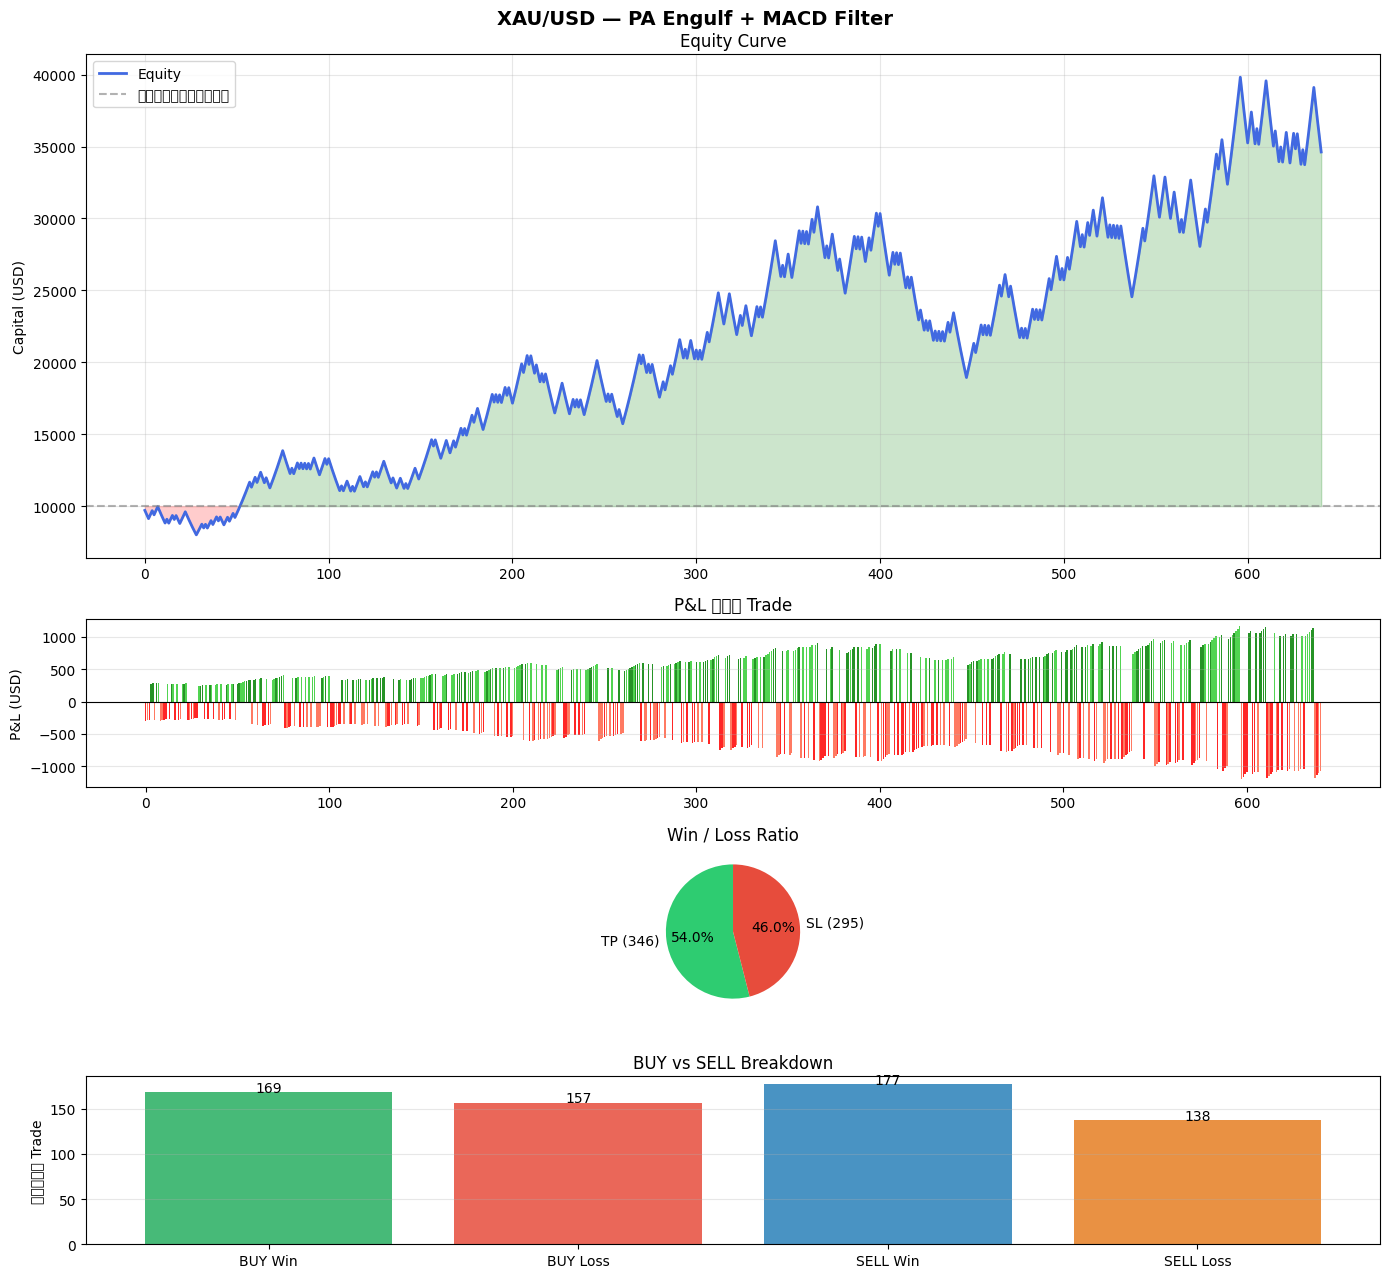

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ดาวน์โหลดเสร็จแล้ว!


In [9]:
if not df_trades.empty and 'completed' in dir() and not completed.empty:
    fig, axes = plt.subplots(4, 1, figsize=(14, 13), gridspec_kw={'height_ratios': [3,1,1,1]})
    fig.suptitle('XAU/USD — PA Engulf + MACD Filter', fontsize=14, fontweight='bold')

    eq  = completed['capital'].values
    ax1 = axes[0]
    ax1.plot(range(len(eq)), eq, color='royalblue', linewidth=2, label='Equity')
    ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle='--', alpha=0.6, label='ทุนเริ่มต้น')
    ax1.fill_between(range(len(eq)), INITIAL_CAPITAL, eq,
                     where=[e >= INITIAL_CAPITAL for e in eq], alpha=0.2, color='green')
    ax1.fill_between(range(len(eq)), INITIAL_CAPITAL, eq,
                     where=[e <  INITIAL_CAPITAL for e in eq], alpha=0.2, color='red')
    ax1.set_ylabel('Capital (USD)'); ax1.set_title('Equity Curve')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    bar_colors = []
    for _, r in completed.iterrows():
        if r['result'] == 'TP':
            bar_colors.append('green' if r['direction'] == 'BUY' else 'limegreen')
        else:
            bar_colors.append('red' if r['direction'] == 'BUY' else 'tomato')
    ax2.bar(range(len(completed)), completed['pnl'], color=bar_colors, alpha=0.85)
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.set_ylabel('P&L (USD)'); ax2.set_title('P&L ต่อ Trade')
    ax2.grid(True, alpha=0.3, axis='y')

    ax3 = axes[2]
    ax3.pie([len(wins), len(loses)],
            labels=[f'TP ({len(wins)})', f'SL ({len(loses)})'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
    ax3.set_title('Win / Loss Ratio')

    ax4 = axes[3]
    categories = ['BUY Win', 'BUY Loss', 'SELL Win', 'SELL Loss']
    values     = [len(buy_wins), len(buys)-len(buy_wins),
                  len(sell_wins), len(sells)-len(sell_wins)]
    colors4    = ['#27ae60','#e74c3c','#2980b9','#e67e22']
    ax4.bar(categories, values, color=colors4, alpha=0.85)
    for j, v in enumerate(values):
        ax4.text(j, v + 0.1, str(v), ha='center', fontsize=10)
    ax4.set_title('BUY vs SELL Breakdown'); ax4.set_ylabel('จำนวน Trade')
    ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('pa_macd_v2_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    completed.to_csv('pa_macd_v2_tradelog.csv', index=False)

    from google.colab import files
    files.download('pa_macd_v2_tradelog.csv')
    files.download('pa_macd_v2_result.png')
    print('ดาวน์โหลดเสร็จแล้ว!')

In [10]:
# ===== EXPORT DATA FOR DASHBOARD =====
# Exports all backtest results as JSON for use with the dashboard HTML template
# The dashboard HTML is available at: https://github.com/supanutdear/XAU-USD-Backtest-Dashboard-PA-Engulf-MACD-EMA50

from collections import Counter
import json
from google.colab import files

# Equity curve
eq_capital = [INITIAL_CAPITAL] + completed['capital'].round(2).tolist()
eq_labels  = ['Start'] + pd.to_datetime(completed['entry_time']).dt.strftime('%b %Y').tolist()
eq_results = [''] + completed['result'].tolist()
eq_peak    = [INITIAL_CAPITAL]
cur_peak   = INITIAL_CAPITAL
for c in completed['capital'].tolist():
    cur_peak = max(cur_peak, c)
    eq_peak.append(round(cur_peak, 2))

# Annual breakdown
completed['year'] = pd.to_datetime(completed['entry_time']).dt.year
annual_rows = []
for year, grp in completed.groupby('year'):
    yr_wins  = grp[grp['result'] == 'TP']
    yr_start = grp['capital'].iloc[0] - grp['pnl'].iloc[0]
    yr_end   = grp['capital'].iloc[-1]
    yr_ret   = (yr_end / yr_start - 1) * 100 if yr_start > 0 else 0
    annual_rows.append({
        'year': int(year), 'trades': len(grp),
        'wins': len(yr_wins), 'losses': len(grp) - len(yr_wins),
        'wr': round(len(yr_wins) / len(grp) * 100, 1),
        'pnl': round(grp['pnl'].sum(), 2),
        'ret': round(yr_ret, 1)
    })

# Loss streak distribution
streaks, cur = [], 0
for r in completed['result']:
    if r == 'SL': cur += 1
    else:
        if cur > 0: streaks.append(cur)
        cur = 0
if cur > 0: streaks.append(cur)
streak_dist = dict(Counter(streaks))

# Conditional probability
results_list = completed['result'].tolist()
base_wr_val  = len(wins) / total * 100
cond_rows = []
for streak_len in range(1, 6):
    for outcome in ['TP', 'SL']:
        tm, nw = 0, 0
        for idx in range(streak_len, len(results_list)):
            if all(r == outcome for r in results_list[idx-streak_len:idx]):
                tm += 1
                if results_list[idx] == 'TP': nw += 1
        if tm >= 5:
            pw = round(nw / tm * 100, 1)
            cond_rows.append({
                'label': f'{"Win" if outcome == "TP" else "Loss"} {streak_len} streak',
                'pct': pw, 'diff': round(pw - base_wr_val, 1), 'n': tm
            })

# Summary
dashboard_data = {
    'config': {
        'initial_capital': INITIAL_CAPITAL,
        'risk_pct': RISK_PERCENT * 100,
        'rr_ratio': RR_RATIO,
        'max_sl_pct': MAX_SL_PCT,
        'macd': f'{MACD_FAST}/{MACD_SLOW}/{MACD_SIGNAL}',
        'ema': f'EMA{EMA_FAST}',
    },
    'results': {
        'final_capital': round(completed['capital'].iloc[-1], 2),
        'total_return': round((completed['capital'].iloc[-1] / INITIAL_CAPITAL - 1) * 100, 1),
        'total_trades': total,
        'wins': len(wins), 'losses': len(loses),
        'win_rate': round(len(wins) / total * 100, 1),
        'profit_factor': round(pf, 2),
        'max_drawdown': round(max_dd, 2),
        'sharpe': sharpe, 'sortino': sortino, 'calmar': calmar,
        'buy_wr': round(buy_wr, 1), 'sell_wr': round(sell_wr, 1),
        'max_win_streak': max_win_streak, 'max_loss_streak': max_loss_streak,
    },
    'equity': {'capital': eq_capital, 'labels': eq_labels, 'peak': eq_peak, 'results': eq_results},
    'annual': annual_rows,
    'conditional_probability': cond_rows,
    'loss_streak_distribution': streak_dist,
}

with open('backtest_data.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

files.download('backtest_data.json')
print('Export complete!')
print(f'  Equity points : {len(eq_capital)}')
print(f'  Annual rows   : {len(annual_rows)}')
print(f'  Cond prob rows: {len(cond_rows)}')
print(f'  Streak dist   : {streak_dist}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Export complete!
  Equity points : 642
  Annual rows   : 5
  Cond prob rows: 10
  Streak dist   : {3: 16, 1: 93, 4: 11, 2: 30, 6: 3, 5: 5, 7: 1}
